## Import libs

In [1]:
from sklearn.model_selection import train_test_split
import seaborn as sns

from tensorflow.keras.optimizers import Adam
from tensorflow.data import Dataset

from falsb4mpa.dataset.load_data import load_data
from falsb4mpa.evaluation.evaluation import compute_predictive_metrics, compute_fair_metrics, compute_tradeoff, compute_intersectional_fair_metrics
from falsb4mpa.modeling.vanilla_lr.model import VanillaLogisticRegression
from falsb4mpa.modeling.vanilla_lr.learning import train_loop

from falsb4mpa.evaluation.evaluation import evaluation

## Preliminaries

In [2]:
batch_size = 64
epochs = 100
learning_rate = 0.0001
opt = Adam(learning_rate=learning_rate)

In [3]:
cv_seeds = [13]
# cv_seeds = [13, 29, 42, 55, 73]

## Load data

In [4]:
data_name = 'adult-mpa-cat-wout-agg'

In [5]:
x, y, a1, a2 = load_data(data_name)
raw_data = (x, y, a1, a2)

In [6]:
xdim = x.shape[1]
ydim = y.shape[1]
a1dim = a1.shape[1]
a2dim = a2.shape[1]
zdim = 8
print(xdim, ydim, a1dim, a2dim, zdim)

102 1 1 5 8


## Result file

In [7]:
header = "model_name", "cv_seed", "clas_acc", "a1_dp", "a1_deqodds", "a1_deqopp", "a1_TN_g0", "a1_FP_g0", "a1_FN_g0", "a1_TP_g0", "a1_TN_g1", "a1_FP_g1", "a1_FN_g1", "a1_TP_g1", "a0_dp", "a0_deqodds", "a0_deqopp", "a0_TN_g0", "a0_FP_g0", "a0_FN_g0", "a0_TP_g0", "a0_TN_g1", "a0_FP_g1", "a0_FN_g1", "a0_TP_g1"

results = []

## Testing

In [8]:
results= []
for cv_seed in cv_seeds:
        x_train, x_test, y_train, y_test, a1_train, a1_test, a2_train, a2_test = train_test_split(
                x, y, a1, a2, test_size=0.3, random_state=cv_seed
        )
        
        train_data = Dataset.from_tensor_slices((x_train, y_train, a1_train, a2_train))
        train_data = train_data.batch(batch_size, drop_remainder=True)

        test_data = Dataset.from_tensor_slices((x_test, y_test, a1_test, a2_test))
        test_data = test_data.batch(batch_size, drop_remainder=True)
        
        model = VanillaLogisticRegression(xdim, ydim, batch_size)
        ret = train_loop(model, train_data, epochs)
        
        Y, A1, A2, Y_hat = evaluation(model, test_data)

        clas_acc, clas_f1_micro, clas_f1_macro, confusion_matrix = compute_predictive_metrics(Y, Y_hat)
        
        a1_dp, a1_deqodds, a1_deqopp, a1_metrics_g0, a1_metrics_g1 = compute_fair_metrics(Y, A1, Y_hat, a1dim)
        a2_dp, a2_deqodds, a2_deqopp = compute_fair_metrics(Y, A2, Y_hat, a2dim)

        wc_spd, wc_aod, wc_eod = compute_intersectional_fair_metrics(Y, A1, A2, Y_hat, a1dim, a2dim)
        
        # fair_metrics = (dp, deqodds, deqopp)
        
        # tradeoff = []
        
        # for fair_metric in fair_metrics:
        #         tradeoff.append(compute_tradeoff(clas_acc, fair_metric))
        
        # result = ['UnfairLR-decay', cv_seed, clas_acc, dp, deqodds, deqopp, tradeoff[0], tradeoff[1], tradeoff[2]]

        result = ['VanillaLR', cv_seed, clas_acc, a1_dp, a1_deqodds, a1_deqopp] + a1_metrics_g0 + a1_metrics_g1 
        result += [a2_dp, a2_deqodds, a2_deqopp]
        result += [wc_spd, wc_aod, wc_eod]

        results.append(result)
        

> Epoch | Class Loss | Class Acc


2026-05-05 10:42:16.238982: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 1 | 0.4712148606777191 | 0.6181363866396761


2026-05-05 10:42:18.007496: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 2 | 0.40466639399528503 | 0.7908337550607287
> 3 | 0.38185882568359375 | 0.813733552631579


...

> 16 | 0.3407256007194519 | 0.830086032388664
> 17 | 0.3399733901023865 | 0.830560475708502
> 18 | 0.33928680419921875 | 0.8307502530364372
> 19 | 0.33865654468536377 | 0.8309716599190283
> 20 | 0.33807504177093506 | 0.8310032894736842
> 21 | 0.3375360667705536 | 0.831066548582996
> 22 | 0.3370344936847687 | 0.8311614372469636
> 23 | 0.3365659713745117 | 0.8315093623481782
> 24 | 0.3361268937587738 | 0.8317307692307693
> 25 | 0.335714191198349 | 0.8320154352226721
> 26 | 0.33532506227493286 | 0.8321419534412956
> 27 | 0.33495745062828064 | 0.8321735829959515
> 28 | 0.33460915088653564 | 0.8321735829959515
> 29 | 0.33427858352661133 | 0.8323633603238867
> 30 | 0.33396416902542114 | 0.8323317307692307
> 31 | 0.33366459608078003 | 0.8324266194331984


2026-05-05 10:43:10.656217: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 32 | 0.3333786725997925 | 0.832521508097166
> 33 | 0.33310526609420776 | 0.8325531376518218
> 34 | 0.332843542098999 | 0.832521508097166
> 35 | 0.33259254693984985 | 0.8326796558704453
> 36 | 0.33235156536102295 | 0.8326480263157895
> 37 | 0.3321199417114258 | 0.8327112854251012
> 38 | 0.3318970203399658 | 0.8328061740890689
> 39 | 0.3316822648048401 | 0.8329326923076923
> 40 | 0.33147507905960083 | 0.8330908400809717
> 41 | 0.33127516508102417 | 0.832995951417004
> 42 | 0.33108192682266235 | 0.8329643218623481
> 43 | 0.33089500665664673 | 0.8330592105263158
> 44 | 0.3307141363620758 | 0.8331224696356275
> 45 | 0.3305388391017914 | 0.8330592105263158
> 46 | 0.3303689956665039 | 0.832995951417004
> 47 | 0.3302041292190552 | 0.832995951417004
> 48 | 0.3300440311431885 | 0.8330592105263158
> 49 | 0.3298885226249695 | 0.8331857287449392
> 50 | 0.32973742485046387 | 0.8332173582995951
> 51 | 0.329590380191803 | 0.833248987854251
> 52 | 0.32944726943969727 | 0.8334703947368421
> 53 | 0.329

2026-05-05 10:44:05.977601: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 64 | 0.3279802203178406 | 0.833755060728745
> 65 | 0.3278750479221344 | 0.833755060728745
> 66 | 0.3277720510959625 | 0.8338183198380567
> 67 | 0.3276711702346802 | 0.8338183198380567
> 68 | 0.3275722861289978 | 0.8338499493927125
> 69 | 0.327475368976593 | 0.8338815789473685
> 70 | 0.32738029956817627 | 0.8340080971659919
> 71 | 0.32728704810142517 | 0.8340080971659919
> 72 | 0.32719558477401733 | 0.8340397267206477
> 73 | 0.3271058201789856 | 0.8340397267206477
> 74 | 0.3270176649093628 | 0.8340397267206477
> 75 | 0.3269311189651489 | 0.8340080971659919
> 76 | 0.3268461227416992 | 0.8339448380566802
> 77 | 0.3267625570297241 | 0.8339448380566802
> 78 | 0.3266804814338684 | 0.8337866902834008
> 79 | 0.3265998065471649 | 0.833755060728745
> 80 | 0.32652047276496887 | 0.8338183198380567
> 81 | 0.32644250988960266 | 0.8337866902834008
> 82 | 0.32636576890945435 | 0.8338183198380567
> 83 | 0.3262902498245239 | 0.8338499493927125
> 84 | 0.3262159824371338 | 0.8338499493927125
> 85 | 0.32

In [9]:
print(clas_acc, clas_f1_micro, clas_f1_macro)

0.83345675 0.8334567535545023 0.7555652918266529


<Axes: >

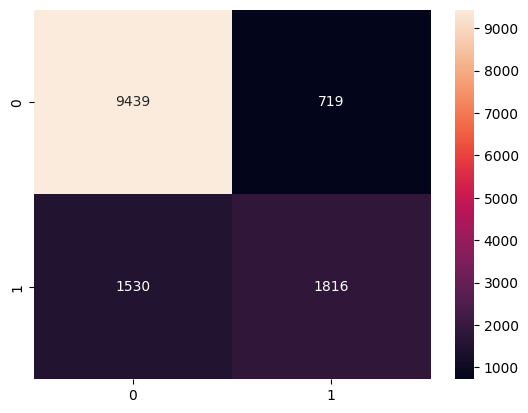

In [10]:
sns.heatmap(confusion_matrix, annot=True, fmt='g')

## Saving into DF then CSV

In [11]:
# result_df = pd.DataFrame(results, columns=header)
# result_df

In [12]:
# result_df.to_csv(f'{data_name}-result/unfair_lr-{epochs}.csv')